# Iteration 6: Language-Aware Longest-Text Undersampling with Strong Regularisation — RQ1

This iteration replaces the SMOTE-based oversampling strategy of Iteration 5 with a **language-aware longest-text undersampling** approach. Instead of synthesising new minority samples, the majority class is reduced to a 1:1 ratio by retaining only those non-process-safety reports with the longest combined text, under the hypothesis that longer incident narratives carry richer semantic signal and improve decision-boundary quality.

**Research Question 1 (RQ1):** Can the classification of *Process Safety* incidents across multilingual and domain-specific datasets be improved by at least **6.75 percentage points** in macro-average F1-score (from approximately 0.7825 to at least 0.85) compared with the baseline BERT & SVM model?


## Experimental Design

| Component | Configuration |
|---|---|
| **Embedding models** | 6 multilingual transformers (stable subset from Iterations 4–5) |
| **Datasets** | English, German, Swedish, Dutch (country-level manual annotations) |
| **Balancing** | Longest-text undersampling to 1:1 ratio (no synthetic oversampling) |
| **Classifiers** | Linear SVM (calibrated), RBF SVM, XGBoost, LightGBM, Random Forest |
| **Regularisation** | Strong: SVM C=0.01, RF max_depth=10, min_samples_split=10, min_samples_leaf=5 |
| **Threshold optimisation** | Per-classifier threshold search targeting ≥ 95% PS recall |
| **Class weighting** | 10× multiplier on Process Safety class |
| **Evaluation** | Macro F1, per-class precision/recall/F1, confusion matrices, ROC & PR curves |

## Outputs
- Per-model, per-dataset cached embeddings (`.npy`) in `Embeddings/_iteration_6/`
- Academic-quality confusion matrix, metrics bar chart, ROC, and precision-recall plots (PNG @ 300 dpi + vector PDF) in `Results/_iteration_6/`
- Detailed results JSON/CSV and summary report with gap analysis against RQ1 baseline

# 1. Configuration, Path Resolution, and Constants

This cell establishes the project environment for Iteration 6. It locates the project root directory, validates the master dataset, defines dataset file paths for all four country-level subsets, and initialises the configuration dictionary and checkpoint utilities required for reproducible pipeline execution.

In [1]:
# =============================================================================
# CONFIGURATION & RESET UTILITIES — ITERATION 6 (FIXED)
# =============================================================================

import os
import gc
import json
import glob
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')


def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    """Search upward from start_path for directory containing a Datasets or Master Dataset folder."""
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists() or (cur / 'Master Dataset 34k').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        "Could not find project root with 'Datasets' or 'Master Dataset 34k'. "
        "Set THESIS_BASE_DIR or run from inside the thesis project."
    )


env_base = os.environ.get('THESIS_BASE_DIR')
BASE_DIR = Path(env_base).resolve() if env_base else find_project_root_with_datasets(Path.cwd())
print(f"Using BASE_DIR: {BASE_DIR}")

PATHS = {
    'master_dataset': BASE_DIR / 'Master Dataset 34k',
    'embeddings': BASE_DIR / 'Embeddings' / '_iteration_6',
    'results': BASE_DIR / 'Results' / '_iteration_6',
}
for k, p in PATHS.items():
    p.mkdir(parents=True, exist_ok=True)

DATA_DIR = PATHS['master_dataset']
EMBEDDINGS_BASE_DIR = PATHS['embeddings']
RESULTS_DIR = PATHS['results']
CHECKPOINT_FILE = RESULTS_DIR / 'checkpoint_iteration_6.json'

DATASET_FILES = {
    'english_manual': DATA_DIR / 'By_SL_Country' / 'master_df_English_manual.json',
    'german_manual': DATA_DIR / 'By_SL_Country' / 'master_df_Germany_manual.json',
    'swedish_manual': DATA_DIR / 'By_SL_Country' / 'master_df_Sweden_manual.json',
    'dutch_manual': DATA_DIR / 'By_SL_Country' / 'master_df_Netherlands_manual.json',
}
DATASET_FILES = {k: v for k, v in DATASET_FILES.items() if v.exists()}
print(f"Dataset files available: {list(DATASET_FILES.keys())}")

CONFIG = {
    'pooling_strategy': 'mean',
    'use_feature_scaling': True,
    'use_undersampling': True,
    'undersample_strategy': 1.0,   # 1:1 class ratio
    'undersample_method': 'longest_text',
    'strong_regularization': True,
    'ps_weight_multiplier': 10,
    'target_ps_recall': 0.95,
    'target_macro_f1': 0.98,
    'max_samples_svm': 6000,
    'batch_size': 12,
    'max_length': 512,
    'random_state': 42,
}

# Only keep stable multilingual embedding models here.
MODELS = {
    'bert-base-multilingual-uncased': 'google-bert/bert-base-multilingual-uncased',
    'xlm-roberta-base': 'xlm-roberta-base',
    'paraphrase-multilingual-mpnet-base-v2': 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
    'paraphrase-multilingual-MiniLM-L12-v2': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
    'snowflake-arctic-embed-l-v2.0': 'snowflake/snowflake-arctic-embed-l-v2.0',
    'multilingual-e5-large-instruct': 'intfloat/multilingual-e5-large-instruct',
}


def save_checkpoint(processed_items):
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump({'processed': sorted([list(x) for x in processed_items])}, f, indent=2)


def load_checkpoint():
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
        return {tuple(item) for item in data.get('processed', [])}
    return set()


def reset_checkpoint():
    if CHECKPOINT_FILE.exists():
        CHECKPOINT_FILE.unlink()
        print('[OK] Checkpoint deleted')
    else:
        print('[INFO] No checkpoint found')


def reset_iteration6_outputs():
    reset_checkpoint()
    for folder in [EMBEDDINGS_BASE_DIR, RESULTS_DIR]:
        if folder.exists():
            shutil.rmtree(folder)
        folder.mkdir(parents=True, exist_ok=True)
    print('[OK] Iteration 6 outputs reset')


print('\nIteration 6 configuration:')
for k, v in CONFIG.items():
    print(f"  - {k}: {v}")
print(f"\nModels: {list(MODELS.keys())}")


Using BASE_DIR: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
Dataset files available: ['english_manual', 'german_manual', 'swedish_manual', 'dutch_manual']

Iteration 6 configuration:
  - pooling_strategy: mean
  - use_feature_scaling: True
  - use_undersampling: True
  - undersample_strategy: 1.0
  - undersample_method: longest_text
  - strong_regularization: True
  - ps_weight_multiplier: 10
  - target_ps_recall: 0.95
  - target_macro_f1: 0.98
  - max_samples_svm: 6000
  - batch_size: 12
  - max_length: 512
  - random_state: 42

Models: ['bert-base-multilingual-uncased', 'xlm-roberta-base', 'paraphrase-multilingual-mpnet-base-v2', 'paraphrase-multilingual-MiniLM-L12-v2', 'snowflake-arctic-embed-l-v2.0', 'multilingual-e5-large-instruct']


# 2. Imports, Data Loading, and Embedding Helpers

This cell imports the machine learning and transformer libraries, detects the available compute device (MPS / CUDA / CPU), loads all four country-level datasets, and defines the embedding generation and mean-pooling helper functions used in the subsequent pipeline steps.

In [ ]:
# =============================================================================
# IMPORTS, DATA LOADING, AND EMBEDDING HELPERS
# =============================================================================

import time
import os
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple, Optional, List

from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
print(f'Using device: {DEVICE}')


def load_language_datasets(dataset_files: Dict[str, Path]) -> Dict[str, pd.DataFrame]:
    loaded = {}
    for key, path in dataset_files.items():
        df = pd.read_json(path)
        required_cols = ['TITLE', 'CASE_DESCRIPTION', 'CASE_TYPE']
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"{key}: missing required columns: {missing}")
        loaded[key] = df.reset_index(drop=True)
        print(f"[OK] {key}: {len(df):,} rows")
    return loaded


loaded_data = load_language_datasets(DATASET_FILES)


def combine_text(df: pd.DataFrame) -> pd.Series:
    title = df['TITLE'].fillna('').astype(str)
    desc = df['CASE_DESCRIPTION'].fillna('').astype(str)
    return title + '. ' + desc


def text_length(df: pd.DataFrame) -> np.ndarray:
    return (
        df['TITLE'].fillna('').astype(str).str.len()
        + df['CASE_DESCRIPTION'].fillna('').astype(str).str.len()
    ).to_numpy()


def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def get_document_embeddings(texts: List[str], model_name: str, batch_size: int = 12, max_length: int = 512) -> np.ndarray:
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModel.from_pretrained(model_name, trust_remote_code=True).to(DEVICE)
    model.eval()

    if tokenizer.pad_token is None and tokenizer.eos_token is not None:
        tokenizer.pad_token = tokenizer.eos_token

    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f'Embedding {model_name}'):
        batch = texts[i:i + batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        ).to(DEVICE)
        with torch.no_grad():
            outputs = model(**inputs)
            hs = outputs.last_hidden_state if hasattr(outputs, 'last_hidden_state') else outputs[0]
            pooled = mean_pool(hs, inputs['attention_mask'])
        all_embs.append(pooled.cpu().numpy())
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        elif DEVICE == 'mps' and hasattr(torch.mps, 'empty_cache'):
            torch.mps.empty_cache()
    del model
    gc.collect()
    return np.vstack(all_embs)


def embedding_filename(model_key: str, dataset_key: str) -> Path:
    return EMBEDDINGS_BASE_DIR / f"embeddings_{model_key}_{dataset_key}_mean.npy"

Using device: cpu
[OK] english_manual: 4,713 rows
[OK] german_manual: 14,951 rows
[OK] swedish_manual: 12,224 rows
[OK] dutch_manual: 1,990 rows


# 3. Reuse or Generate Embeddings

This cell checks for cached `.npy` embedding files in `Embeddings/_iteration_6/`. If a file for a given model–dataset pair already exists — or can be copied from a previous iteration (5, 4, 3, …) — it is reused without re-loading the transformer model. Only missing embeddings are generated from scratch.

In [ ]:
# =============================================================================
# STEP 1 — REUSE OR GENERATE EMBEDDINGS
# =============================================================================

processed = load_checkpoint()
print(f'Checkpoint entries loaded: {len(processed)}')

# Optionally reuse iteration 4/5 embeddings if available.
def copy_existing_embedding_if_found(model_key: str, dataset_key: str) -> bool:
    target = embedding_filename(model_key, dataset_key)
    if target.exists():
        return True
    for prev_iter in [5, 4, 3, 2, 1, 0]:
        prev_dir = BASE_DIR / 'Embeddings' / f'_iteration_{prev_iter}'
        candidate = prev_dir / target.name
        if candidate.exists():
            shutil.copy2(candidate, target)
            print(f'[COPY] {candidate.name} from _iteration_{prev_iter}')
            return True
    return False

for dataset_key, df in loaded_data.items():
    texts = combine_text(df).tolist()
    for model_key, model_name in MODELS.items():
        pair = (model_key, dataset_key)
        out_file = embedding_filename(model_key, dataset_key)
        if out_file.exists() or copy_existing_embedding_if_found(model_key, dataset_key):
            print(f'[INFO] Cached: {out_file.name}')
            processed.add(pair)
            save_checkpoint(processed)
            continue
        print(f'\n[RUN] {dataset_key} + {model_key}')
        try:
            embs = get_document_embeddings(
                texts,
                model_name=model_name,
                batch_size=CONFIG['batch_size'],
                max_length=CONFIG['max_length']
            )
            np.save(out_file, embs)
            print(f'[OK] Saved embeddings: {out_file.name} -> {embs.shape}')
            processed.add(pair)
            save_checkpoint(processed)
        except Exception as e:
            print(f'[ERROR] Embedding failed for {model_key} on {dataset_key}: {e}')
            continue

print('\nEmbedding preparation complete.')


Checkpoint entries loaded: 0
[COPY] embeddings_bert-base-multilingual-uncased_english_manual_mean.npy from _iteration_5
[COPY] embeddings_xlm-roberta-base_english_manual_mean.npy from _iteration_5
[COPY] embeddings_paraphrase-multilingual-mpnet-base-v2_english_manual_mean.npy from _iteration_5
[COPY] embeddings_paraphrase-multilingual-MiniLM-L12-v2_english_manual_mean.npy from _iteration_5
[COPY] embeddings_snowflake-arctic-embed-l-v2.0_english_manual_mean.npy from _iteration_5

[RUN] english_manual + multilingual-e5-large-instruct


Embedding intfloat/multilingual-e5-large-instruct: 100%|██████████| 393/393 [09:37<00:00,  1.47s/it]


[OK] Saved embeddings: embeddings_multilingual-e5-large-instruct_english_manual_mean.npy -> (4713, 1024)
[COPY] embeddings_bert-base-multilingual-uncased_german_manual_mean.npy from _iteration_5
[COPY] embeddings_xlm-roberta-base_german_manual_mean.npy from _iteration_5
[COPY] embeddings_paraphrase-multilingual-mpnet-base-v2_german_manual_mean.npy from _iteration_5
[COPY] embeddings_paraphrase-multilingual-MiniLM-L12-v2_german_manual_mean.npy from _iteration_5
[COPY] embeddings_snowflake-arctic-embed-l-v2.0_german_manual_mean.npy from _iteration_5

[RUN] german_manual + multilingual-e5-large-instruct


Embedding intfloat/multilingual-e5-large-instruct: 100%|██████████| 1246/1246 [26:42<00:00,  1.29s/it]


[OK] Saved embeddings: embeddings_multilingual-e5-large-instruct_german_manual_mean.npy -> (14951, 1024)
[COPY] embeddings_bert-base-multilingual-uncased_swedish_manual_mean.npy from _iteration_5
[COPY] embeddings_xlm-roberta-base_swedish_manual_mean.npy from _iteration_5
[COPY] embeddings_paraphrase-multilingual-mpnet-base-v2_swedish_manual_mean.npy from _iteration_5
[COPY] embeddings_paraphrase-multilingual-MiniLM-L12-v2_swedish_manual_mean.npy from _iteration_5
[COPY] embeddings_snowflake-arctic-embed-l-v2.0_swedish_manual_mean.npy from _iteration_5

[RUN] swedish_manual + multilingual-e5-large-instruct


Embedding intfloat/multilingual-e5-large-instruct: 100%|██████████| 1019/1019 [17:50<00:00,  1.05s/it]


[OK] Saved embeddings: embeddings_multilingual-e5-large-instruct_swedish_manual_mean.npy -> (12224, 1024)
[COPY] embeddings_bert-base-multilingual-uncased_dutch_manual_mean.npy from _iteration_5
[COPY] embeddings_xlm-roberta-base_dutch_manual_mean.npy from _iteration_5
[COPY] embeddings_paraphrase-multilingual-mpnet-base-v2_dutch_manual_mean.npy from _iteration_5
[COPY] embeddings_paraphrase-multilingual-MiniLM-L12-v2_dutch_manual_mean.npy from _iteration_5
[COPY] embeddings_snowflake-arctic-embed-l-v2.0_dutch_manual_mean.npy from _iteration_5

[RUN] dutch_manual + multilingual-e5-large-instruct


Embedding intfloat/multilingual-e5-large-instruct: 100%|██████████| 166/166 [13:04<00:00,  4.73s/it]


[OK] Saved embeddings: embeddings_multilingual-e5-large-instruct_dutch_manual_mean.npy -> (1990, 1024)

Embedding preparation complete.


# 4. Prepare Training Packages with Longest-Text Undersampling

This cell constructs balanced training sets by retaining all minority-class (Process Safety) samples and selecting the longest-text majority-class samples to achieve a 1:1 ratio. Feature scaling is fitted on the original (pre-undersampling) training split to avoid data leakage, then applied to both balanced training data and the held-out test set.

In [4]:
# =============================================================================
# STEP 2 — PREPARE TRAINING PACKAGES WITH LONGEST-TEXT UNDERSAMPLING
# =============================================================================

from sklearn.utils import resample


def make_balanced_train_split(
    X_train: np.ndarray,
    y_train: np.ndarray,
    train_idx: np.ndarray,
    df: pd.DataFrame,
    ratio: float = 1.0
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Keep all minority examples and select the longest-text majority examples to reach the target ratio."""
    train_df = df.iloc[train_idx].copy()
    train_df['label'] = y_train
    train_df['orig_pos'] = np.arange(len(train_df))
    train_df['text_len'] = text_length(train_df)

    class_counts = train_df['label'].value_counts().to_dict()
    if len(class_counts) < 2:
        return X_train, y_train, train_df

    minority_class = min(class_counts, key=class_counts.get)
    majority_class = max(class_counts, key=class_counts.get)
    n_min = class_counts[minority_class]
    target_majority = int(n_min / ratio)

    minority_df = train_df[train_df['label'] == minority_class].copy()
    majority_df = train_df[train_df['label'] == majority_class].copy()
    majority_df = majority_df.sort_values('text_len', ascending=False).head(target_majority)

    balanced_df = pd.concat([minority_df, majority_df], axis=0)
    balanced_df = balanced_df.sample(frac=1.0, random_state=CONFIG['random_state']).reset_index(drop=True)

    keep_positions = balanced_df['orig_pos'].to_numpy()
    X_bal = X_train[keep_positions]
    y_bal = balanced_df['label'].to_numpy()
    return X_bal, y_bal, balanced_df


def prepare_embedding_for_training(npy_file: Path, dataset_key: str, model_key: str, df: pd.DataFrame):
    embeddings = np.load(npy_file)
    if len(embeddings) != len(df):
        raise ValueError(f'Embedding rows ({len(embeddings)}) do not match dataframe rows ({len(df)}) for {dataset_key}')

    labels = (df['CASE_TYPE'] == 'Process Safety').astype(int).to_numpy()
    indices = np.arange(len(df))

    idx_train, idx_test = train_test_split(
        indices,
        test_size=0.2,
        random_state=CONFIG['random_state'],
        stratify=labels,
    )

    X_train = embeddings[idx_train]
    X_test = embeddings[idx_test]
    y_train = labels[idx_train]
    y_test = labels[idx_test]

    # Fit scaler on original (pre-undersampling) X_train to avoid data leakage
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_bal, y_train_bal, balanced_df = make_balanced_train_split(
        X_train, y_train, idx_train, df, ratio=CONFIG['undersample_strategy']
    )
    X_train_scaled = scaler.transform(X_train_bal)

    return {
        'X_train_balanced': X_train_scaled,
        'y_train_balanced': y_train_bal,
        'X_test_scaled': X_test_scaled,
        'y_test': y_test,
        'metadata': {
            'dataset': dataset_key,
            'model_key': model_key,
            'train_original': int(len(y_train)),
            'train_balanced': int(len(y_train_bal)),
            'test_size': int(len(y_test)),
            'ps_train_balanced': int((y_train_bal == 1).sum()),
            'nps_train_balanced': int((y_train_bal == 0).sum()),
        }
    }


training_packages = []
for dataset_key, df in loaded_data.items():
    for model_key in MODELS.keys():
        npy_file = embedding_filename(model_key, dataset_key)
        if not npy_file.exists():
            print(f'[SKIP] Missing embeddings for {dataset_key} + {model_key}')
            continue
        try:
            pkg = prepare_embedding_for_training(npy_file, dataset_key, model_key, df)
            training_packages.append((npy_file, pkg))
            meta = pkg['metadata']
            print(f"[OK] {dataset_key} + {model_key}: train {meta['train_original']} -> {meta['train_balanced']} | test {meta['test_size']}")
        except Exception as e:
            print(f'[ERROR] Failed to prepare {dataset_key} + {model_key}: {e}')

print(f'\nPrepared {len(training_packages)} training packages')


[OK] english_manual + bert-base-multilingual-uncased: train 3770 -> 2254 | test 943
[OK] english_manual + xlm-roberta-base: train 3770 -> 2254 | test 943
[OK] english_manual + paraphrase-multilingual-mpnet-base-v2: train 3770 -> 2254 | test 943
[OK] english_manual + paraphrase-multilingual-MiniLM-L12-v2: train 3770 -> 2254 | test 943
[OK] english_manual + snowflake-arctic-embed-l-v2.0: train 3770 -> 2254 | test 943
[OK] english_manual + multilingual-e5-large-instruct: train 3770 -> 2254 | test 943
[OK] german_manual + bert-base-multilingual-uncased: train 11960 -> 2658 | test 2991
[OK] german_manual + xlm-roberta-base: train 11960 -> 2658 | test 2991
[OK] german_manual + paraphrase-multilingual-mpnet-base-v2: train 11960 -> 2658 | test 2991
[OK] german_manual + paraphrase-multilingual-MiniLM-L12-v2: train 11960 -> 2658 | test 2991
[OK] german_manual + snowflake-arctic-embed-l-v2.0: train 11960 -> 2658 | test 2991
[OK] german_manual + multilingual-e5-large-instruct: train 11960 -> 2658 

# 5. Classifier Training, Evaluation, and Academic Visualisation

This cell trains five classifiers (Linear SVM calibrated, RBF SVM, XGBoost, LightGBM, Random Forest) for each model–dataset combination and performs per-classifier threshold optimisation targeting ≥ 95% PS recall. For every trained classifier, separate academic-quality figures are saved:
- **Confusion matrix** — `figsize=(8,6)`, 300 dpi, Times New Roman, PNG + PDF
- **Metrics bar chart** — per-class precision, recall, F1, and macro F1
- **ROC curve** — with AUC annotation and random baseline
- **Precision-Recall curve** — with Average Precision annotation

In [ ]:
# =============================================================================
# STEP 3 — CLASSIFIER TRAINING, EVALUATION, AND ACADEMIC VISUALISATION
# =============================================================================

# ── Academic plotting helpers (thesis standard: Times New Roman, 8×6, 300 dpi) ──

def _apply_academic_rcparams():
    """Apply thesis-standard matplotlib rcParams (Times New Roman serif)."""
    matplotlib.rcParams.update({
        'font.family': 'serif',
        'font.serif':  ['Times New Roman', 'DejaVu Serif'],
        'font.size':   13,
    })


def _restore_rcparams():
    """Restore default matplotlib rcParams after academic plotting."""
    matplotlib.rcParams.update(matplotlib.rcParamsDefault)


def _save_academic_figure(fig, base_name):
    """Save figure as PNG (300 dpi) + PDF and close."""
    png_path = RESULTS_DIR / f'{base_name}.png'
    pdf_path = RESULTS_DIR / f'{base_name}.pdf'
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print(f"    [OK] Saved: {base_name}.png + .pdf")
    plt.close(fig)


def _plot_confusion_matrix(cm, dataset_name, model_name, clf_name):
    """Academic-quality confusion matrix (thesis standard)."""
    _apply_academic_rcparams()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Non-Process Safety', 'Process Safety'],
        yticklabels=['Non-Process Safety', 'Process Safety'],
        cbar_kws={'label': 'Count', 'shrink': 0.8},
        linewidths=0.8, linecolor='white',
        annot_kws={'size': 18, 'fontweight': 'bold'},
        ax=ax,
    )
    ax.set_title(
        f'Confusion Matrix — {dataset_name.upper()} ({model_name}, {clf_name})',
        fontsize=18, fontweight='bold', pad=14,
    )
    ax.set_ylabel('True Label', fontsize=16)
    ax.set_xlabel('Predicted Label', fontsize=16)
    ax.tick_params(labelsize=13)
    fig.tight_layout()

    base = f"confusion_matrix_{dataset_name}_{model_name.replace('/', '_')}_{clf_name}"
    _save_academic_figure(fig, base)
    _restore_rcparams()


def _plot_metrics_bar(metrics_dict, dataset_name, model_name, clf_name):
    """Academic-quality per-class metrics bar chart."""
    _apply_academic_rcparams()

    labels = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    n_ps = sum(1 for l in labels if 'PS' in l and 'NPS' not in l and 'Macro' not in l)
    n_nps = sum(1 for l in labels if 'NPS' in l)
    colors = (['#2e86c1'] * n_ps) + (['#27ae60'] * n_nps) + (['#c0392b'] * (len(labels) - n_ps - n_nps))

    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score', fontsize=16)
    ax.set_title(
        f'Classification Metrics — {dataset_name.upper()} ({model_name}, {clf_name})',
        fontsize=18, fontweight='bold', pad=14,
    )
    ax.tick_params(axis='x', rotation=45, labelsize=11)
    ax.tick_params(axis='y', labelsize=13)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    fig.tight_layout()
    base = f"metrics_bar_{dataset_name}_{model_name.replace('/', '_')}_{clf_name}"
    _save_academic_figure(fig, base)
    _restore_rcparams()


def _plot_roc_curve(y_true, y_proba, dataset_name, model_name, clf_name):
    """Academic-quality ROC curve with AUC."""
    if y_proba is None:
        return
    _apply_academic_rcparams()

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc_val = roc_auc_score(y_true, y_proba)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, color='#2e86c1', lw=2, label=f'ROC Curve (AUC = {auc_val:.4f})')
    ax.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random Baseline')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=16)
    ax.set_ylabel('True Positive Rate', fontsize=16)
    ax.set_title(
        f'ROC Curve — {dataset_name.upper()} ({model_name}, {clf_name})',
        fontsize=18, fontweight='bold', pad=14,
    )
    ax.legend(loc='lower right', fontsize=13)
    ax.tick_params(labelsize=13)
    fig.tight_layout()

    base = f"roc_curve_{dataset_name}_{model_name.replace('/', '_')}_{clf_name}"
    _save_academic_figure(fig, base)
    _restore_rcparams()


def _plot_precision_recall_curve(y_true, y_proba, dataset_name, model_name, clf_name):
    """Academic-quality Precision-Recall curve with Average Precision."""
    if y_proba is None:
        return
    _apply_academic_rcparams()

    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall_vals, precision_vals, color='#c0392b', lw=2,
            label=f'PR Curve (AP = {ap:.4f})')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall', fontsize=16)
    ax.set_ylabel('Precision', fontsize=16)
    ax.set_title(
        f'Precision-Recall Curve — {dataset_name.upper()} ({model_name}, {clf_name})',
        fontsize=18, fontweight='bold', pad=14,
    )
    ax.legend(loc='upper right', fontsize=13)
    ax.tick_params(labelsize=13)
    fig.tight_layout()

    base = f"pr_curve_{dataset_name}_{model_name.replace('/', '_')}_{clf_name}"
    _save_academic_figure(fig, base)
    _restore_rcparams()


# ── Threshold optimisation and classifier definitions ────────────────────────

def optimize_threshold_for_recall(y_true, y_proba, target_recall=0.95):
    best = {'threshold': 0.5, 'macro_f1': -1, 'ps_recall': 0.0}
    for thr in np.arange(0.1, 0.91, 0.05):
        y_pred = (y_proba >= thr).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
        ps_recall = r[1]
        macro_f1 = np.mean(f1)
        if ps_recall >= target_recall and macro_f1 > best['macro_f1']:
            best = {'threshold': float(thr), 'macro_f1': float(macro_f1), 'ps_recall': float(ps_recall)}
    return best


def get_classifiers(class_weight_dict=None):
    if class_weight_dict is None:
        class_weight_dict = {0: 1, 1: CONFIG['ps_weight_multiplier']}

    clf = {
        'svm_linear': CalibratedClassifierCV(
            LinearSVC(C=0.01, class_weight=class_weight_dict, max_iter=10000, random_state=42, dual=True),
            cv=3,
            method='sigmoid',
        ),
        'svm_rbf': SVC(C=1.0, kernel='rbf', class_weight=class_weight_dict, probability=True, random_state=42),
        'random_forest': RandomForestClassifier(
            n_estimators=100, max_depth=10, min_samples_split=10, min_samples_leaf=5,
            class_weight=class_weight_dict, random_state=42, n_jobs=-1,
        )
    }
    if XGBOOST_AVAILABLE:
        clf['xgboost'] = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=class_weight_dict[1] / class_weight_dict[0],
            reg_alpha=0.1, reg_lambda=1.0, random_state=42,
            use_label_encoder=False, eval_metric='logloss'
        )
    if LIGHTGBM_AVAILABLE:
        clf['lightgbm'] = LGBMClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            class_weight=class_weight_dict, reg_alpha=0.1, reg_lambda=1.0,
            random_state=42, verbose=-1,
        )
    return clf


# ── Main training and evaluation loop ────────────────────────────────────────

all_results = []
for pkg_idx, (_, pkg) in enumerate(training_packages, start=1):
    meta = pkg['metadata']
    dataset_name = meta['dataset']
    model_name = meta['model_key']
    print(f"\n[{pkg_idx}/{len(training_packages)}] {dataset_name} + {model_name}")

    X_train = pkg['X_train_balanced']
    y_train = pkg['y_train_balanced']
    X_test = pkg['X_test_scaled']
    y_test = pkg['y_test']

    class_weight_dict = {0: 1, 1: CONFIG['ps_weight_multiplier']}
    classifiers = get_classifiers(class_weight_dict=class_weight_dict)

    for clf_name, clf in classifiers.items():
        try:
            t0 = time.time()
            clf.fit(X_train, y_train)
            train_time = time.time() - t0

            if hasattr(clf, 'predict_proba'):
                y_proba = clf.predict_proba(X_test)[:, 1]
                thr_info = optimize_threshold_for_recall(y_test, y_proba, target_recall=CONFIG['target_ps_recall'])
                threshold = thr_info['threshold'] if thr_info['macro_f1'] >= 0 else 0.5
                y_pred = (y_proba >= threshold).astype(int)
            else:
                y_proba = None
                threshold = None
                y_pred = clf.predict(X_test)

            report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
            cm = confusion_matrix(y_test, y_pred)
            tn, fp, fn, tp = cm.ravel()

            row = {
                'dataset': dataset_name,
                'model': model_name,
                'classifier': clf_name,
                'accuracy': float(accuracy_score(y_test, y_pred)),
                'macro_f1': float(report['macro avg']['f1-score']),
                'weighted_f1': float(report['weighted avg']['f1-score']),
                'ps_precision': float(report['1']['precision']),
                'ps_recall': float(report['1']['recall']),
                'ps_f1': float(report['1']['f1-score']),
                'nps_precision': float(report['0']['precision']),
                'nps_recall': float(report['0']['recall']),
                'nps_f1': float(report['0']['f1-score']),
                'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
                'threshold': threshold,
                'train_time_seconds': float(train_time),
                'train_original': meta['train_original'],
                'train_balanced': meta['train_balanced'],
                'ps_train_balanced': meta['ps_train_balanced'],
                'nps_train_balanced': meta['nps_train_balanced'],
            }
            all_results.append(row)
            print(f"  [OK] {clf_name:14s} | macro_f1={row['macro_f1']:.4f} | ps_recall={row['ps_recall']:.4f}")

            # ── Generate 4 separate academic figures per classifier ──
            _plot_confusion_matrix(cm, dataset_name, model_name, clf_name)

            metrics_dict = {
                'Prec PS': row['ps_precision'],
                'Rec PS': row['ps_recall'],
                'F1 PS': row['ps_f1'],
                'Prec NPS': row['nps_precision'],
                'Rec NPS': row['nps_recall'],
                'F1 NPS': row['nps_f1'],
                'Macro F1': row['macro_f1'],
            }
            _plot_metrics_bar(metrics_dict, dataset_name, model_name, clf_name)

            _plot_roc_curve(y_test, y_proba, dataset_name, model_name, clf_name)

            _plot_precision_recall_curve(y_test, y_proba, dataset_name, model_name, clf_name)

        except Exception as e:
            print(f"  [ERROR] {clf_name}: {e}")
            continue

results_df = pd.DataFrame(all_results)
results_json = RESULTS_DIR / 'iteration_6_all_results.json'
results_csv = RESULTS_DIR / 'iteration_6_all_results.csv'
results_df.to_json(results_json, orient='records', indent=2)
results_df.to_csv(results_csv, index=False)

print('\nTraining complete.')
print(f'Results saved to: {results_json}')
if len(results_df):
    display(results_df.sort_values('macro_f1', ascending=False).head(10))


[1/24] english_manual + bert-base-multilingual-uncased
  [OK] svm_linear     | macro_f1=0.4443 | ps_recall=0.9645
  [OK] svm_rbf        | macro_f1=0.4424 | ps_recall=0.9716
  [OK] random_forest  | macro_f1=0.3381 | ps_recall=0.9787
  [OK] xgboost        | macro_f1=0.4083 | ps_recall=0.9610
  [OK] lightgbm       | macro_f1=0.4526 | ps_recall=0.9504

[2/24] english_manual + xlm-roberta-base
  [OK] svm_linear     | macro_f1=0.4796 | ps_recall=0.9539
  [OK] svm_rbf        | macro_f1=0.4750 | ps_recall=0.9539
  [OK] random_forest  | macro_f1=0.4238 | ps_recall=0.9574
  [OK] xgboost        | macro_f1=0.4005 | ps_recall=0.9610
  [OK] lightgbm       | macro_f1=0.4475 | ps_recall=0.9539

[3/24] english_manual + paraphrase-multilingual-mpnet-base-v2
  [OK] svm_linear     | macro_f1=0.4820 | ps_recall=0.9539
  [OK] svm_rbf        | macro_f1=0.5437 | ps_recall=0.9539
  [OK] random_forest  | macro_f1=0.4049 | ps_recall=0.9681
  [OK] xgboost        | macro_f1=0.4667 | ps_recall=0.9539
  [OK] lightg

,dataset,model,classifier,accuracy,macro_f1,weighted_f1,ps_precision,ps_recall,ps_f1,tn,fp,fn,tp,threshold,train_time_seconds,train_original,train_balanced,ps_train_balanced,nps_train_balanced
11,english_manual,paraphrase-multilingual-mpnet-base-v2,svm_rbf,0.544008,0.543688,0.538826,0.392128,0.953901,0.555785,244,417,13,269,0.20,8.925786,3770,2254,1127,1127
26,english_manual,multilingual-e5-large-instruct,svm_rbf,0.523860,0.522821,0.513873,0.381560,0.953901,0.545086,225,436,13,269,0.20,13.129016,3770,2254,1127,1127
18,english_manual,paraphrase-multilingual-MiniLM-L12-v2,xgboost,0.512195,0.510649,0.499596,0.375350,0.950355,0.538153,215,446,14,268,0.25,2.632146,3770,2254,1127,1127
25,english_manual,multilingual-e5-large-instruct,svm_linear,0.497349,0.494799,0.480372,0.368132,0.950355,0.530693,201,460,14,268,0.30,2.503488,3770,2254,1127,1127
10,english_manual,paraphrase-multilingual-mpnet-base-v2,svm_linear,0.485684,0.481956,0.464292,0.363023,0.953901,0.525904,189,472,13,269,0.25,4.564812,3770,2254,1127,1127
5,english_manual,xlm-roberta-base,svm_linear,0.483563,0.479628,0.461442,0.362046,0.953901,0.524878,187,474,13,269,0.30,3.223340,3770,2254,1127,1127
16,english_manual,paraphrase-multilingual-MiniLM-L12-v2,svm_rbf,0.481442,0.476459,0.455931,0.362550,0.968085,0.527536,181,480,9,273,0.15,3.556975,3770,2254,1127,1127
109,dutch_manual,paraphrase-multilingual-MiniLM-L12-v2,lightgbm,0.479899,0.475846,0.457084,0.358730,0.957627,0.521940,78,202,5,113,0.30,0.876151,1592,940,470,470
19,english_manual,paraphrase-multilingual-MiniLM-L12-v2,lightgbm,0.480382,0.475712,0.455824,0.361333,0.960993,0.525194,182,479,11,271,0.25,1.170401,3770,2254,1127,1127
6,english_manual,xlm-roberta-base,svm_rbf,0.479321,0.474954,0.455710,0.360107,0.953901,0.522838,183,478,13,269,0.20,9.087118,3770,2254,1127,1127


# 6. Aggregate Visualisations

This cell generates summary-level academic figures across all model–dataset–classifier combinations: best macro F1 per dataset and a precision-recall trade-off scatter plot.

Loaded 120 rows from iteration_6_all_results.json


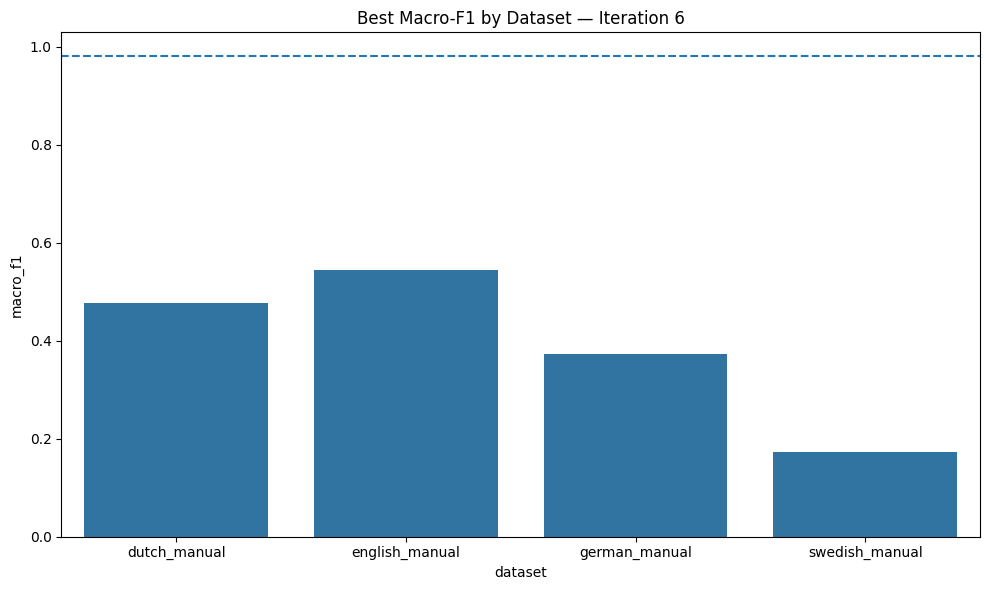

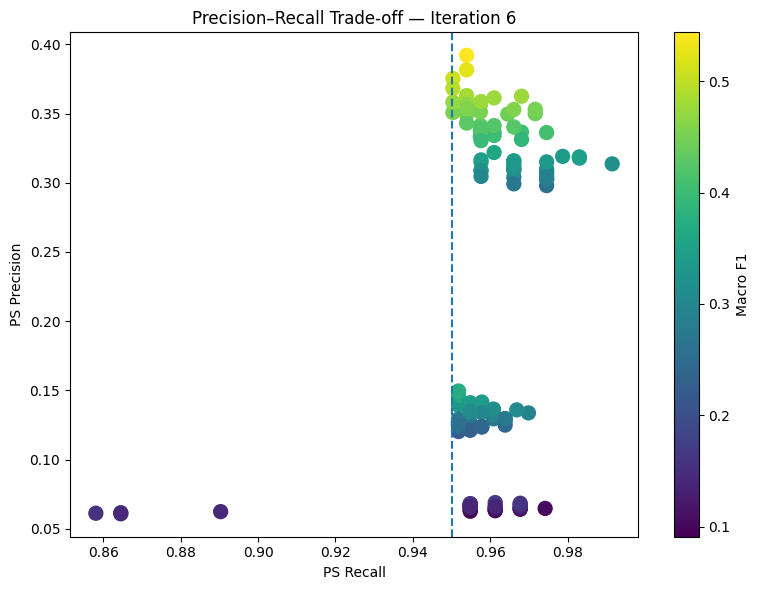

In [ ]:
# =============================================================================
# STEP 4 — AGGREGATE ACADEMIC VISUALISATIONS
# =============================================================================

results_json = RESULTS_DIR / 'iteration_6_all_results.json'
if results_json.exists():
    results_df = pd.read_json(results_json)
    print(f'[OK] Loaded {len(results_df)} rows from {results_json.name}')
else:
    raise FileNotFoundError('Run the training cell first.')

# ── Figure 1: Best Macro-F1 by Dataset ──────────────────────────────────────
_apply_academic_rcparams()
best_by_dataset = results_df.sort_values('macro_f1', ascending=False).groupby('dataset', as_index=False).first()

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(best_by_dataset['dataset'], best_by_dataset['macro_f1'],
              color='#2e86c1', edgecolor='white', linewidth=0.8)
ax.axhline(CONFIG['target_macro_f1'], linestyle='--', color='#c0392b', lw=1.5, label=f"Target (F1 = {CONFIG['target_macro_f1']})")
ax.set_ylim(0, 1.12)
ax.set_ylabel('Macro F1-Score', fontsize=16)
ax.set_xlabel('Dataset', fontsize=16)
ax.set_title('Best Macro-F1 by Dataset — Iteration 6', fontsize=18, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=30, labelsize=11)
ax.tick_params(axis='y', labelsize=13)
ax.legend(fontsize=13)

for bar, val in zip(bars, best_by_dataset['macro_f1']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

fig.tight_layout()
_save_academic_figure(fig, 'best_macro_f1_by_dataset')
_restore_rcparams()

# ── Figure 2: PS Precision vs. PS Recall Scatter ─────────────────────────────
_apply_academic_rcparams()
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    results_df['ps_recall'], results_df['ps_precision'],
    c=results_df['macro_f1'], cmap='viridis', s=100, edgecolors='white', linewidth=0.6
)
ax.axvline(CONFIG['target_ps_recall'], linestyle='--', color='#c0392b', lw=1.5,
           label=f"Target PS Recall ({CONFIG['target_ps_recall']})")
cbar = fig.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('Macro F1-Score', fontsize=13)
ax.set_xlabel('PS Recall', fontsize=16)
ax.set_ylabel('PS Precision', fontsize=16)
ax.set_title('Precision–Recall Trade-off — Iteration 6', fontsize=18, fontweight='bold', pad=14)
ax.tick_params(labelsize=13)
ax.legend(fontsize=13, loc='lower left')

fig.tight_layout()
_save_academic_figure(fig, 'precision_recall_scatter')
_restore_rcparams()

print('[OK] Aggregate visualisations complete.')

# 7. Final Summary Export

This cell computes the gap analysis against the RQ1 baseline (macro F1 ≥ 0.85) and saves `iteration_6_summary.json` containing the best configuration, improvement metrics, and dataset coverage.

In [7]:
# =============================================================================
# STEP 5 — FINAL SUMMARY EXPORT
# =============================================================================

results_json = RESULTS_DIR / 'iteration_6_all_results.json'
if results_json.exists():
    df = pd.read_json(results_json)
    best = df.loc[df['macro_f1'].idxmax()]
    summary = {
        'iteration': 6,
        'model_family': 'multilingual embeddings + longest-text undersampling (no SMOTE)',
        'strategy': 'Class-balanced longest-text undersampling with strong regularization',
        'datasets': sorted(df['dataset'].unique().tolist()),
        'best_result': {
            'embedding_model': str(best['model']),
            'classifier': str(best['classifier']),
            'dataset': str(best['dataset']),
            'macro_f1': round(float(best['macro_f1']), 4),
            'ps_precision': round(float(best['ps_precision']), 4),
            'ps_recall': round(float(best['ps_recall']), 4),
            'accuracy': round(float(best['accuracy']), 4),
        },
        'gap_analysis': {
            'current_macro_f1': round(float(best['macro_f1']), 4),
            'rq1_target': 0.85,
            'baseline': 0.7825,
            'gap': round(float(0.85 - best['macro_f1']), 4),
            'improvement_over_baseline': round(float(best['macro_f1'] - 0.7825), 4),
        }
    }
    with open(RESULTS_DIR / 'iteration_6_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    print('[OK] Saved iteration_6_summary.json')
    print('\nBest configuration:')
    print(json.dumps(summary['best_result'], indent=2))
else:
    print('[INFO] Run the training cell first.')


[OK] Saved iteration_6_summary.json

Best configuration:
{
  "embedding_model": "paraphrase-multilingual-mpnet-base-v2",
  "classifier": "svm_rbf",
  "dataset": "english_manual",
  "macro_f1": 0.5437,
  "ps_precision": 0.3921,
  "ps_recall": 0.9539,
  "accuracy": 0.544
}
